<table align="center" width="100%">
    <tr>
        <td width="15%" align="center">
            <img src="https://img.icons8.com/fluency/96/security-checked.png" width="70">
        </td>
        <td>
            <div align="center">
                <font size="6"><b>Fake Job Postings Detection System</b></font><br>
            </div>
        </td>
    </tr>
</table>

# **Problem Statement:**

With the growing use of online job portals, many fake job postings have emerged, making it difficult for job seekers to identify genuine opportunities. These fraudulent listings can lead to scams and misuse of personal information.  
 Therefore, there is a need for an automated system that can analyze job postings and accurately detect whether they are real or fake using machine learning and AI techniques.

In [ ]:
# To mount the google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import Libraries**

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## **Loading the Dataset**

In [ ]:
data = pd.read_csv(r'/content/drive/MyDrive/Ariyan CNN DL/fake_job_postings.csv')

In [ ]:
data

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0


In [ ]:
data.head()


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
data.tail()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0
17879,17880,Web Application Developers,"NZ, N, Wellington",Engineering,NaN,Vend is looking for some awesome new talent to...,Who are we?Vend is an award winning web based ...,We want to hear from you if:You have an in-dep...,NaN,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Engineering,0


In [ ]:
# Getting shape of table(Rows,Columns)
data.shape

(17880, 18)

In [ ]:
# The info() method prints information about the DataFrame.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [ ]:
# For getting column names
data.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [ ]:
# The describe() method returns description of the data in the DataFrame.
data.describe(include='all')

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
count,17880.000000,17880,17534,6333,2868,14572,17879,15184,10668,17880.000000,17880.000000,17880.000000,14409,10830,9775,12977,11425,17880.000000
unique,NaN,11231,3105,1337,874,1709,14801,11967,6204,NaN,NaN,NaN,5,7,13,131,37,NaN
top,NaN,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,NaN,NaN,NaN,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,NaN
freq,NaN,311,718,551,142,726,379,410,726,NaN,NaN,NaN,11620,3809,5145,1734,1749,NaN
mean,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,0.795302,0.491723,NaN,NaN,NaN,NaN,NaN,0.048434
std,5161.655742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.202631,0.403492,0.499945,NaN,NaN,NaN,NaN,NaN,0.214688
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4470.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,13410.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000


### Missing Values

In [ ]:
print("\nMissing Values:\n", data.isnull().sum().sort_values(ascending=False))


Missing Values:
 salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
title                      0
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
fraudulent                 0
dtype: int64


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['fraudulent'].value_counts(normalize=True)

,proportion
fraudulent,
0,0.951566
1,0.048434


## **EDA (Exploratory Data Analysis)**

<Axes: xlabel='fraudulent', ylabel='count'>

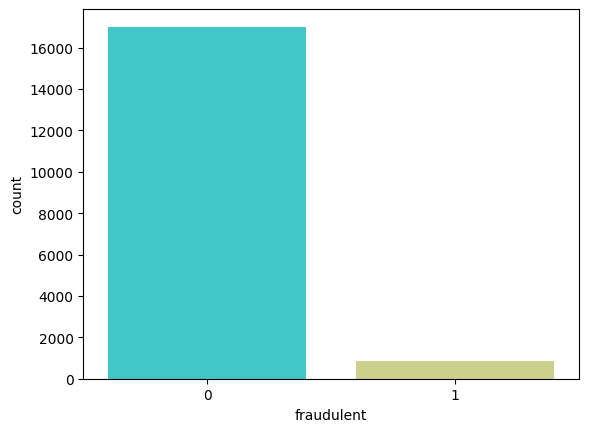

In [ ]:
sns.countplot(data=data,x='fraudulent',palette='rainbow')

As we can see only fake jobs present in the dataset.

Text(0, 0.5, 'No. of Jobs')

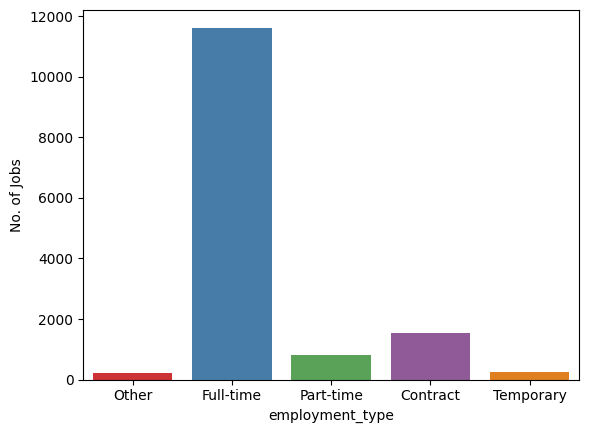

In [ ]:
ax=sns.countplot(data=data, x='employment_type', palette='Set1')
ax.set_ylabel('No. of Jobs')

Majority of job postings are Full-time positions,Very few jobs arePart-time, Contract, or Temporary,indicates dataset is dominated by full-time roles.

In [ ]:
# Separating Categorical and Numerical Columns.
categorical=[]
numerical=[]

for col in data.columns:
    if data[col].dtypes !='object':
            numerical.append(col)
    else:
        categorical.append(col)

In [ ]:
print(len(categorical))
print(categorical)
''
print(len(numerical))
print(numerical)

13
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
5
['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']


<Axes: >

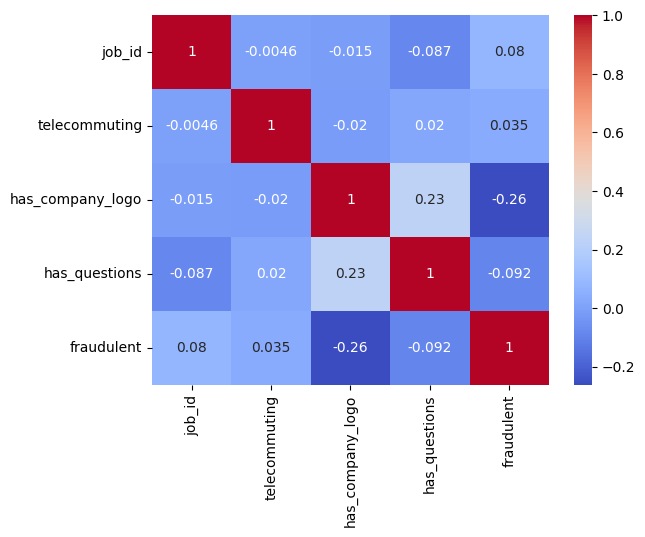

In [ ]:
sns.heatmap(data[numerical].corr(), cmap='coolwarm', annot=True)

Text(0, 0.5, 'No. of Jobs')

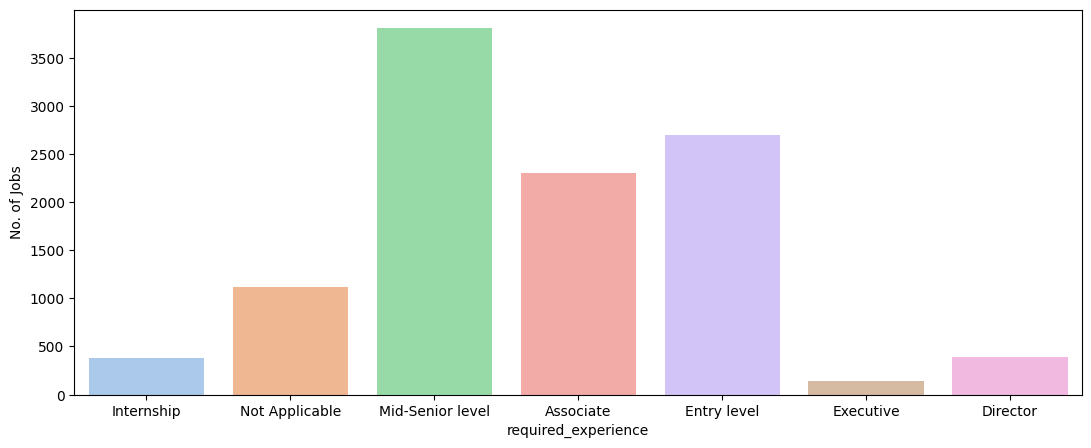

In [ ]:
plt.figure(figsize=(13,5))
ax = sns.countplot(data=data, x='required_experience', palette='pastel')
ax.set_ylabel('No. of Jobs')

## **Data Cleaning**

In [ ]:
# Handling missing values.
data.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [ ]:
# Filling missing values
data.fillna('', inplace=True)

In [ ]:
# Merging columns for prediction
data['text'] = data['title'] + " " + data['description'] + " " + data['requirements']
data = data[['text', 'fraudulent']]

In [ ]:
fake_jobs = data[data['fraudulent'] == 1]
real_jobs = data[data['fraudulent'] == 0]

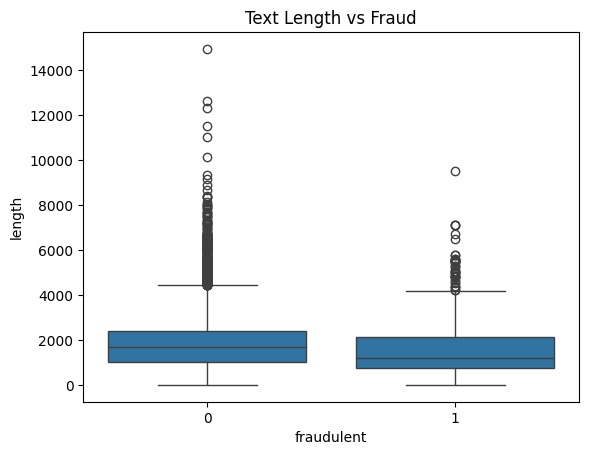

In [ ]:
# Using Boxplot()
data['length'] = data['text'].apply(len)
sns.boxplot(x='fraudulent', y='length', data=data)
plt.title("Text Length vs Fraud")
plt.show()

In [ ]:
data

,text,fraudulent,length
0,"Marketing Intern Food52, a fast-growing, James...",0,1775
1,Customer Service - Cloud Video Production Orga...,0,3553
2,Commissioning Machinery Assistant (CMA) Our cl...,0,1759
3,Account Executive - Washington DC THE COMPANY:...,0,4064
4,Bill Review Manager JOB TITLE: Itemization Rev...,0,2298
...,...,...,...
17875,Account Director - Distribution Just in case ...,0,2749
17876,Payroll Accountant The Payroll Accountant will...,0,1957
17877,Project Cost Control Staff Engineer - Cost Con...,0,2587
17878,Graphic Designer Nemsia Studios is looking for...,0,1026


## **Word Cloud**

(np.float64(-0.5), np.float64(1599.5), np.float64(799.5), np.float64(-0.5))

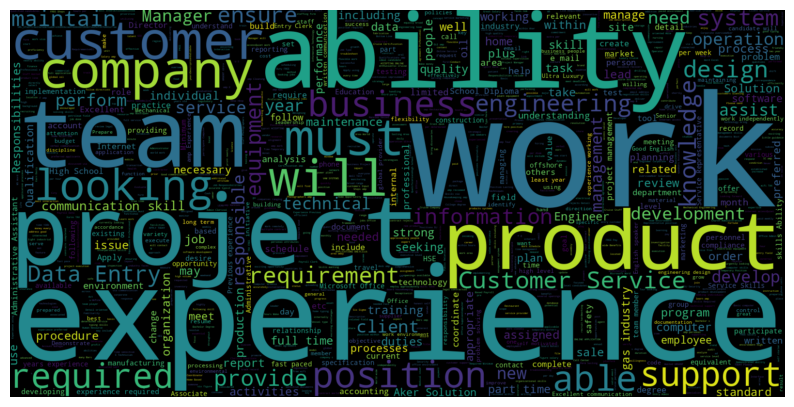

In [ ]:
plt.figure(figsize=(10, 6))
wc = WordCloud(max_words=3000, width=1600, height=800).generate(" ".join(data[data.fraudulent == 1].text))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

(np.float64(-0.5), np.float64(1599.5), np.float64(799.5), np.float64(-0.5))

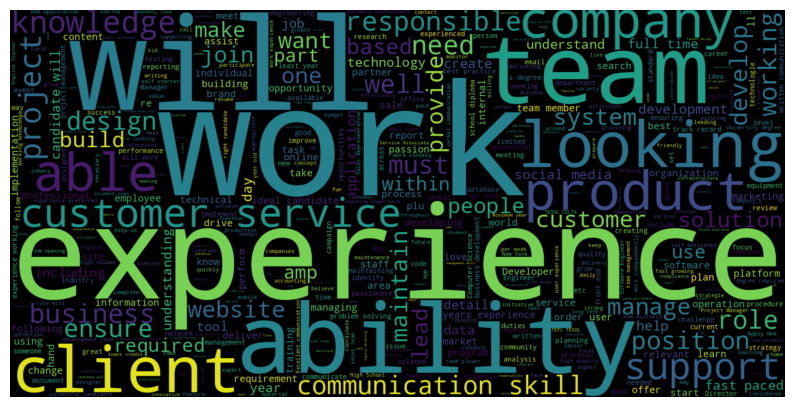

In [ ]:
plt.figure(figsize=(10, 6))
wc = WordCloud(max_words=3000, width=1600, height=800).generate(" ".join(data[data.fraudulent == 0].text))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

## **Text Cleaning / Text Preprocessing**

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]
    return " ".join(words)

data['text'] = data['text'].apply(clean_text)

# **TF-IDF (Term Frequency - Inverse Document Frequency**

In [ ]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X = tfidf.fit_transform(data['text'])
y = data['fraudulent']

# **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14304, 20000)
(3576, 20000)
(14304,)
(3576,)


### SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

## **Model Building and Evaluation**

In [ ]:
lr = LogisticRegression(max_iter=300)
lr.fit(X_train_res, y_train_res)
probs_lr = lr.predict_proba(X_test)[:,1]
y_pred_lr = (probs_lr > 0.3).astype(int)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3403
           1       0.49      0.88      0.63       173

    accuracy                           0.95      3576
   macro avg       0.74      0.92      0.80      3576
weighted avg       0.97      0.95      0.96      3576



In [ ]:
dt = DecisionTreeClassifier(max_depth=20)
dt.fit(X_train_res, y_train_res)

DecisionTreeClassifier(max_depth=20)

## **Model Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
rf = RandomForestClassifier(random_state=42)
param_dist = {
'n_estimators': [100, 150],
'max_depth': [10, 20],
'min_samples_split': [2, 5]
}
rand_search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=2,
    cv=2,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
#  OPTIONAL SPEED BOOST (use subset for tuning)
X_small = X_train_res[:5000]
y_small = y_train_res[:5000]
rand_search.fit(X_small, y_small)
#  Best model
best_rf = rand_search.best_estimator_
#  Train best model on FULL data
best_rf.fit(X_train_res, y_train_res)
# Predictions
probs_rf = best_rf.predict_proba(X_test)[:,1]
y_pred_rf = (probs_rf > 0.3).astype(int)
# Evaluation
print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, probs_rf))

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Random Forest Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.60      0.80      0.68       173

    accuracy                           0.96      3576
   macro avg       0.79      0.89      0.83      3576
weighted avg       0.97      0.96      0.97      3576

ROC-AUC: 0.9674428717265793


### Combining Models

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic', 'Decision Tree', 'Random Forest'],
    'ROC-AUC': [
        roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])

    ]
})


results

,Model,ROC-AUC
0,Logistic,0.978110
1,Decision Tree,0.842414
2,Random Forest,0.967443


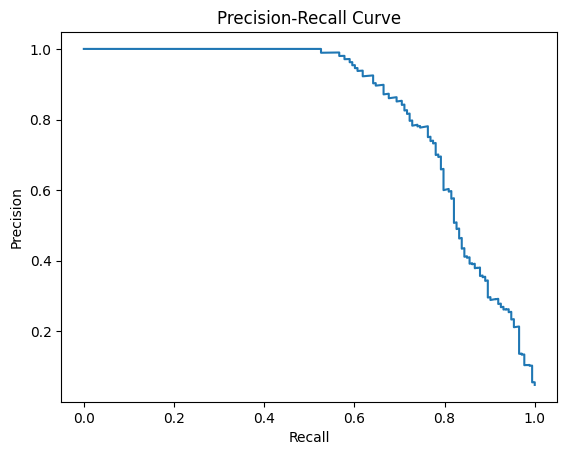

In [ ]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, probs_rf)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## **Building ANN model**

In [ ]:
model = Sequential()

model.add(Dense(256, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train_res, y_train_res,
          epochs=5,
          batch_size=64,
          validation_data=(X_test, y_test))

loss, acc = model.evaluate(X_test, y_test)
print("ANN Accuracy:", acc)

Epoch 1/5
426/426 ━━━━━━━━━━━━━━━━━━━━ 45s 100ms/step - accuracy: 0.9773 - loss: 0.0694 - val_accuracy: 0.9827 - val_loss: 0.0919
Epoch 2/5
426/426 ━━━━━━━━━━━━━━━━━━━━ 75s 85ms/step - accuracy: 0.9992 - loss: 0.0039 - val_accuracy: 0.9824 - val_loss: 0.0761
Epoch 3/5
426/426 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 0.9829 - val_loss: 0.1126
Epoch 4/5
426/426 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9832 - val_loss: 0.0967
Epoch 5/5
426/426 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9835 - val_loss: 0.1093
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9835 - loss: 0.1093
ANN Accuracy: 0.983501136302948


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     5,120,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,459,845 (58.97 MB)

 Trainable params: 5,153,281 (19.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,306,564 (39.32 MB)

### Feature Importance


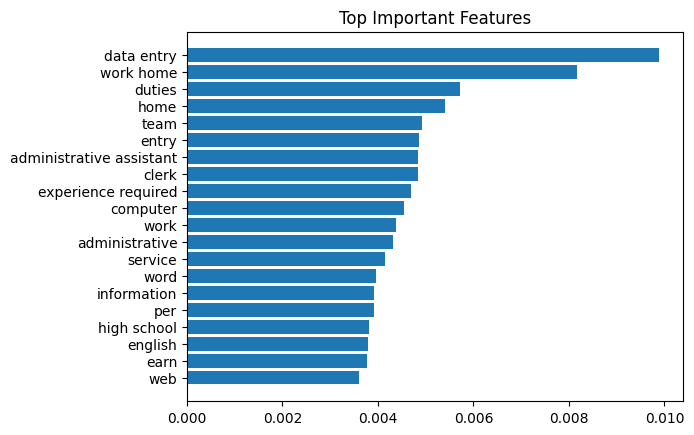

In [ ]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[-20:]
feature_names = tfidf.get_feature_names_out()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top Important Features")
plt.show()

##**Testing the model**

In [ ]:
def test_predict(text):
    clean = clean_text(text)
    vec = tfidf.transform([clean])
    prob = best_rf.predict_proba(vec)[0][1]
    return prob

print("Fake:", test_predict("Earn money fast from home"))
print("Real:", test_predict("Looking for Python developer"))

Fake: 0.25018527561156245
Real: 0.1594536873069013


In [ ]:
data.tail(50)

,text,fraudulent,length
17830,payroll clerk job descriptionwe seeking full t...,1,594
17831,furniture mover earn week mover must exp good ...,1,157
17832,sales controller assistant based heart city ex...,0,2394
17833,web designer looking web designer passion web ...,0,1358
17834,enterprise account executive us engagor lookin...,0,1904
17835,sr business intelligence technical architect e...,0,819
17836,licensed practical nurse lpn private duty want...,0,956
17837,senior backend developers following global exp...,0,1685
17838,senior sales executive simple relevance overvi...,0,1559
17839,sas grid developer job title sas grid develope...,0,1488


In [ ]:
data.text[17874]

'javascript developer sr javascript developer experience years location new yorkexperience front end development experience using javascript html html ajax json javascript css familiar least one javascript mvc framework like backbone url aa fe fcc e b ee cad eea canjs emberjs strong experience accessing rest api including third parties facebook twitter pinterest etc knowledge php sql databases'

In [ ]:
data.text[17830]

'payroll clerk job descriptionwe seeking full time payroll clerk manage day day accounting operation pay scale hrresponsibilities include balancing company accounts processing weekly payroll processing company credit cards processing rebates overall company record keeping job requirements high school diploma equivalent excellent communication organizational skills ability work flexible schedule ability perform mathematical calculations addition subtraction multiplication division percentages'

## **Deploying the Model**

In [ ]:
import joblib
joblib.dump(best_rf, "model.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

['vectorizer.pkl']

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 56.2 MB/s eta 0:00:00


In [ ]:
!pip install streamlit pyngrok

In [ ]:
%%writefile app.py

Writing app.py


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords

# Download once
nltk.download('stopwords')

# ----------------------------
# ⚙️ CONFIG
# ----------------------------
st.set_page_config(
    page_title="Fake Job Detection",
    page_icon="🕵️",
    layout="centered"
)

THRESHOLD = 0.20

# ----------------------------
# 📦 LOAD MODEL
# ----------------------------
model = joblib.load("model.pkl")        # Random Forest
tfidf = joblib.load("vectorizer.pkl")

# ----------------------------
# 🧹 TEXT CLEANING
# ----------------------------
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

# ----------------------------
# 🤖 PREDICTION FUNCTION
# ----------------------------
def predict_job(text):
    clean = clean_text(text)
    vec = tfidf.transform([clean])
    prob = model.predict_proba(vec)[0][1]
    return prob

# ----------------------------
# 🎨 UI
# ----------------------------

st.markdown("<h1 style='text-align:center;'>🕵️ Fake Job Detection System</h1>", unsafe_allow_html=True)
st.markdown("<p style='text-align:center;'>Detect whether a job is <b>Real</b> or <b>Fake</b> using Machine Learning</p>", unsafe_allow_html=True)

st.write("---")

# Input
user_input = st.text_area("📄 Enter Job Description", height=150)

# Example buttons
col1, col2 = st.columns(2)

with col1:
    if st.button("⚠️ Fake Example"):
        user_input = "Earn money fast from home without experience"

with col2:
    if st.button("✅ Real Example"):
        user_input = "Looking for software engineer with Python experience"

# Predict
if st.button("🔍 Predict"):

    if user_input.strip() == "":
        st.warning("Please enter job description")
    else:
        prob = predict_job(user_input)

        st.write("---")

        # 🎯 RESULT
        if prob > THRESHOLD:
            st.error("🚨 FAKE JOB DETECTED")
            confidence = prob
        else:
            st.success("✅ REAL JOB DETECTED")
            confidence = 1 - prob

        # 📊 Confidence bar
        st.write("### Confidence")
        st.progress(int(confidence * 100))
        st.caption(f"{confidence*100:.2f}% confidence")

        # 🧠 Debug (optional - remove in final)
        # st.write("DEBUG Probability:", prob)

Overwriting app.py


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import joblib

# Balance data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Final model
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_res, y_train_res)

# Save correct model
joblib.dump(rf, "model.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

print("FINAL MODEL SAVED")

FINAL MODEL SAVED


In [ ]:
!ls

app.py	drive  model.pkl  sample_data  vectorizer.pkl


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3CdPYHh6JrfmHpqlunb1KhM8y87_vvWJYPCveRqCgkxCa8j8")

In [ ]:
from pyngrok import ngrok
# 🔹 Kill previous sessions
ngrok.kill()
# 🔹 Start Streamlit
get_ipython().system_raw('streamlit run app.py --server.port 8501 &')
# 🔹 Connect ngrok
public_url = ngrok.connect(addr=8501)
print("Your App URL:", public_url)

Your App URL: NgrokTunnel: "https://undertone-falsify-gangly.ngrok-free.dev" -> "http://localhost:8501"
